# 01. Exploratory Data Analysis

Exploración inicial del dataset de Yelp filtrado a restaurantes.

In [9]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_restaurants, load_reviews

sns.set_theme(style='whitegrid')

## 1. Cargar datos

Usamos `max_rows` para una muestra rápida durante desarrollo.

In [10]:
restaurants = load_restaurants()
restaurants.head()

Loading businesses: 150346it [00:01, 145831.33it/s]

Restaurants loaded: 52286


,business_id,name,city,state,stars,review_count,categories,latitude,longitude,is_open
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,Philadelphia,PA,4.0,80,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...",39.955505,-75.155564,1
1,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,Ashland City,TN,2.0,6,"Burgers, Fast Food, Sandwiches, Food, Ice Crea...",36.269593,-87.058943,1
2,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,Affton,MO,3.0,19,"Pubs, Restaurants, Italian, Bars, American (Tr...",38.565165,-90.321087,0
3,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,Nashville,TN,1.5,10,"Ice Cream & Frozen Yogurt, Fast Food, Burgers,...",36.208102,-86.768170,1
4,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,Tampa Bay,FL,4.0,10,"Vietnamese, Food, Restaurants, Food Trucks",27.955269,-82.456320,1


In [11]:
print(f'Total restaurantes: {len(restaurants)}')
print(f'Ciudades únicas: {restaurants["city"].nunique()}')
print(f'Estados únicos: {restaurants["state"].nunique()}')
restaurants.describe()

Total restaurantes: 52286
Ciudades únicas: 920
Estados únicos: 19


,stars,review_count,latitude,longitude,is_open
count,52286.000000,52286.000000,52286.000000,52286.000000,52286.000000
mean,3.515234,87.241078,36.997663,-87.845038,0.669472
std,0.829585,188.912445,6.010943,13.813532,0.470408
min,1.000000,5.000000,27.564457,-120.083748,0.000000
25%,3.000000,13.000000,32.217586,-90.233506,0.000000
50%,3.500000,33.000000,39.484140,-86.035621,1.000000
75%,4.000000,89.000000,39.958370,-75.337533,1.000000
max,5.000000,7568.000000,53.679197,-74.664459,1.000000


## 2. Distribución de ratings

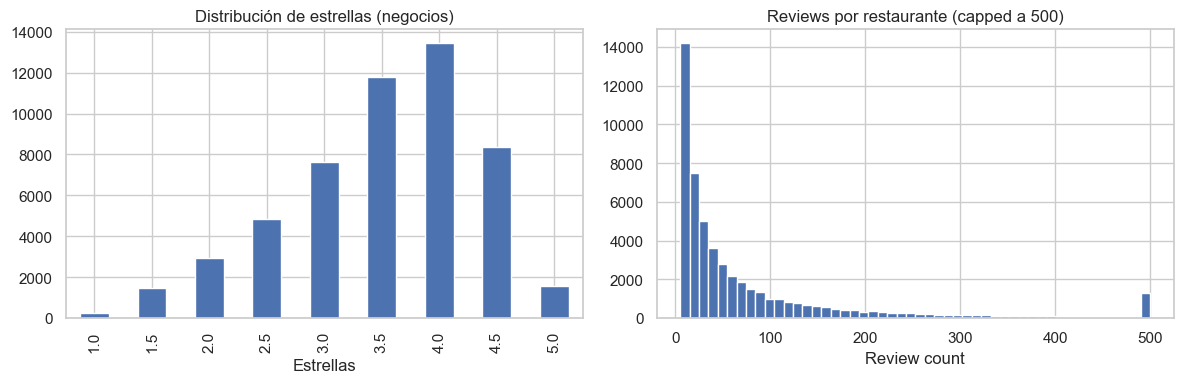

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

restaurants['stars'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribución de estrellas (negocios)')
axes[0].set_xlabel('Estrellas')

restaurants['review_count'].clip(upper=500).hist(bins=50, ax=axes[1])
axes[1].set_title('Reviews por restaurante (capped a 500)')
axes[1].set_xlabel('Review count')

plt.tight_layout()

## 3. Top ciudades con más restaurantes

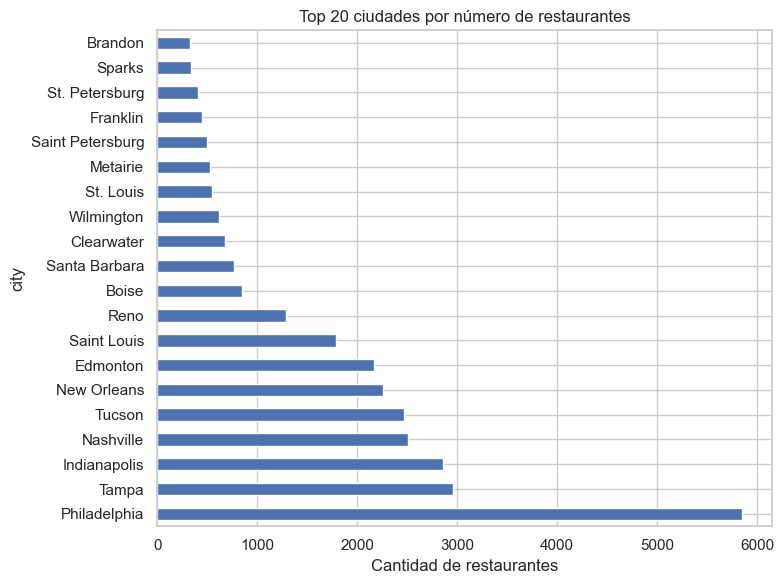

In [13]:
top_cities = restaurants.groupby('city')['business_id'].count().nlargest(20)
top_cities.plot(kind='barh', figsize=(8, 6))
plt.title('Top 20 ciudades por número de restaurantes')
plt.xlabel('Cantidad de restaurantes')
plt.tight_layout()

## 4. Reviews — muestra rápida

In [14]:
rest_ids = set(restaurants['business_id'])
# Para EDA usamos una muestra de 500k reviews
reviews = load_reviews(restaurant_ids=rest_ids, max_rows=500_000)
reviews.head()

Loading reviews: 500000it [00:02, 229691.16it/s]


Reviews loaded: 346460


,review_id,user_id,business_id,stars,text,date,useful
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,0
1,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,0
2,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,1
3,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,1
4,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1.0,I am a long term frequent customer of this est...,2015-09-23 23:10:31,1


Total reviews: 346,460
Usuarios únicos: 231,681
Restaurantes con reviews: 5,162


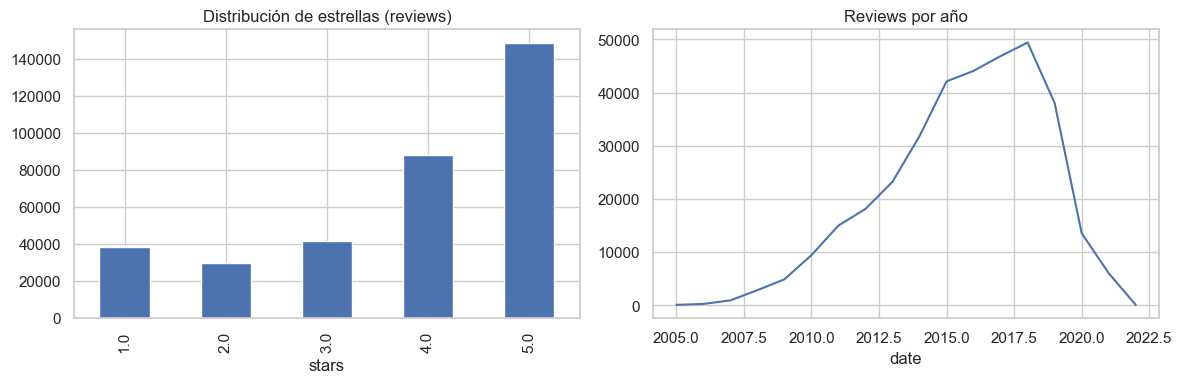

In [15]:
print(f'Total reviews: {len(reviews):,}')
print(f'Usuarios únicos: {reviews["user_id"].nunique():,}')
print(f'Restaurantes con reviews: {reviews["business_id"].nunique():,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
reviews['stars'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribución de estrellas (reviews)')

reviews['date'].dt.year.value_counts().sort_index().plot(ax=axes[1])
axes[1].set_title('Reviews por año')
plt.tight_layout()

## 5. Sparsidad de la matriz usuario-restaurante

In [16]:
n_users = reviews['user_id'].nunique()
n_items = reviews['business_id'].nunique()
n_ratings = len(reviews)
sparsity = 1 - n_ratings / (n_users * n_items)
print(f'Matriz: {n_users} usuarios x {n_items} restaurantes')
print(f'Ratings: {n_ratings}')
print(f'Sparsidad: {sparsity:.4%}')

Matriz: 231681 usuarios x 5162 restaurantes
Ratings: 346460
Sparsidad: 99.9710%
